In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv("placement.csv")

In [53]:
df.sample(5)

,cgpa,placement_exam_marks,placed
257,5.74,76.0,0
153,6.29,10.0,1
697,7.23,49.0,1
16,6.53,19.0,0
608,7.33,16.0,1


<Axes: xlabel='placement_exam_marks', ylabel='Count'>

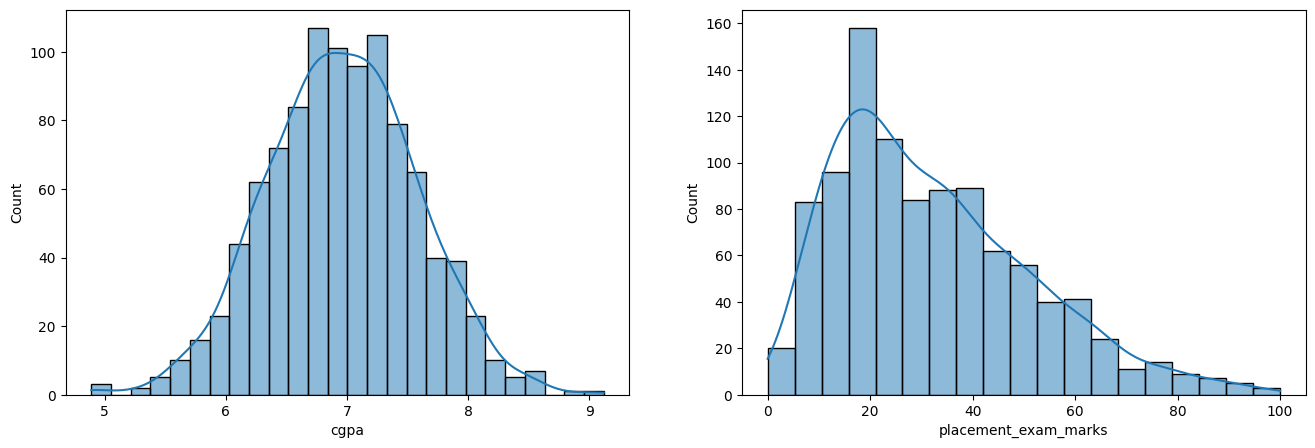

In [54]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)

In [56]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: xlabel='placement_exam_marks'>

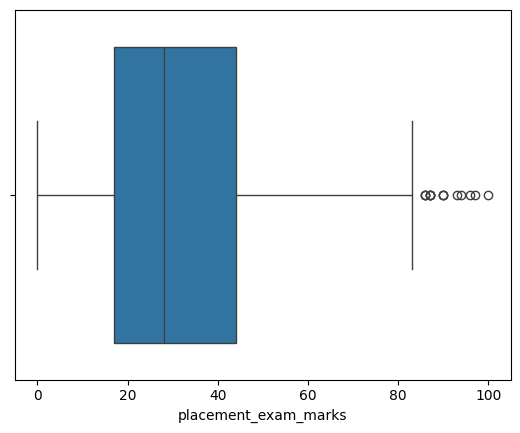

In [60]:
sns.boxplot(df['placement_exam_marks'],orient='h')

In [61]:
percentile25=df['placement_exam_marks'].quantile(0.25)
percentile75=df['placement_exam_marks'].quantile(0.75)

In [62]:
percentile75

np.float64(44.0)

In [63]:
iqr=percentile75 - percentile25

In [64]:
iqr

np.float64(27.0)

In [68]:
upper_limit=percentile75 + 1.5*iqr
lower_limit=percentile25 - 1.5*iqr

In [69]:
print("Upper Limit",upper_limit)
print("Lower Limit",lower_limit)

Upper Limit 84.5
Lower Limit -23.5


In [72]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [73]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


# **Trimming**

In [76]:
new_df=df[df['placement_exam_marks'] < upper_limit]

In [77]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [78]:
new_df.shape , df.shape

((985, 3), (1000, 3))

<Axes: xlabel='placement_exam_marks'>

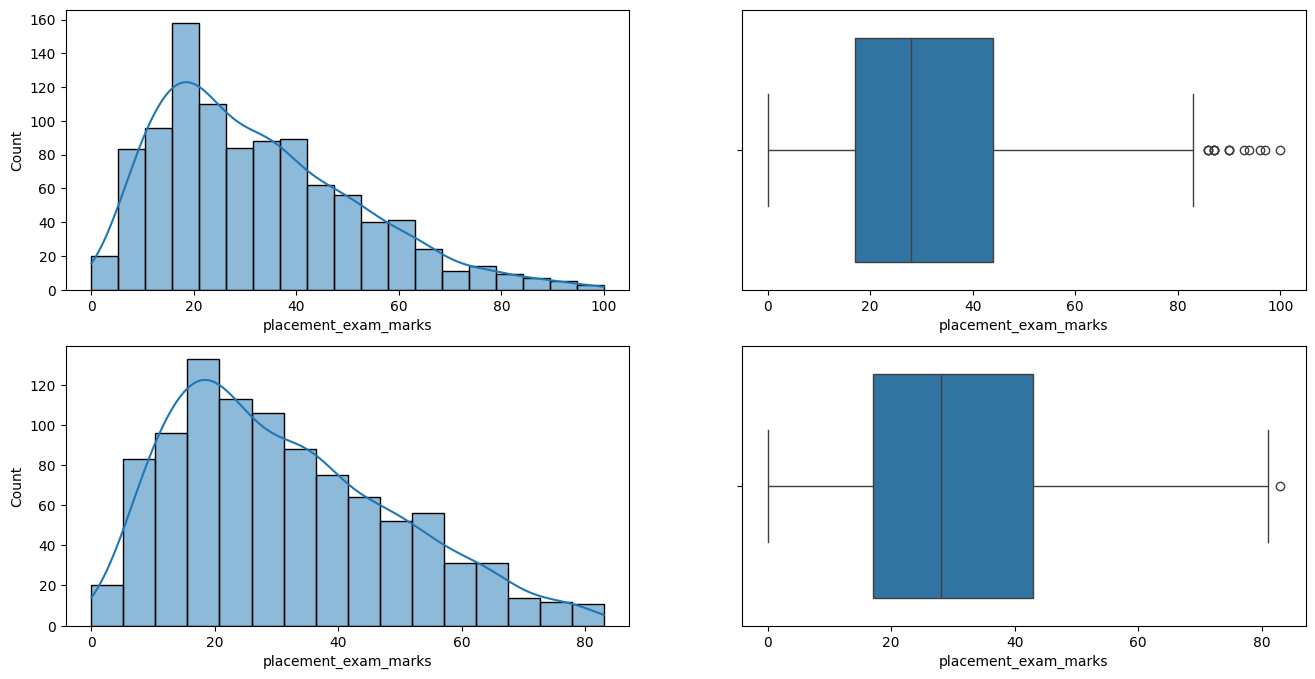

In [79]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'],orient='h')

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'],orient='h')

#**Capping**

In [81]:
new_df_cap=df.copy()

new_df_cap['placement_exam_marks']=np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [82]:
new_df_cap.shape

(1000, 3)

<Axes: xlabel='placement_exam_marks'>

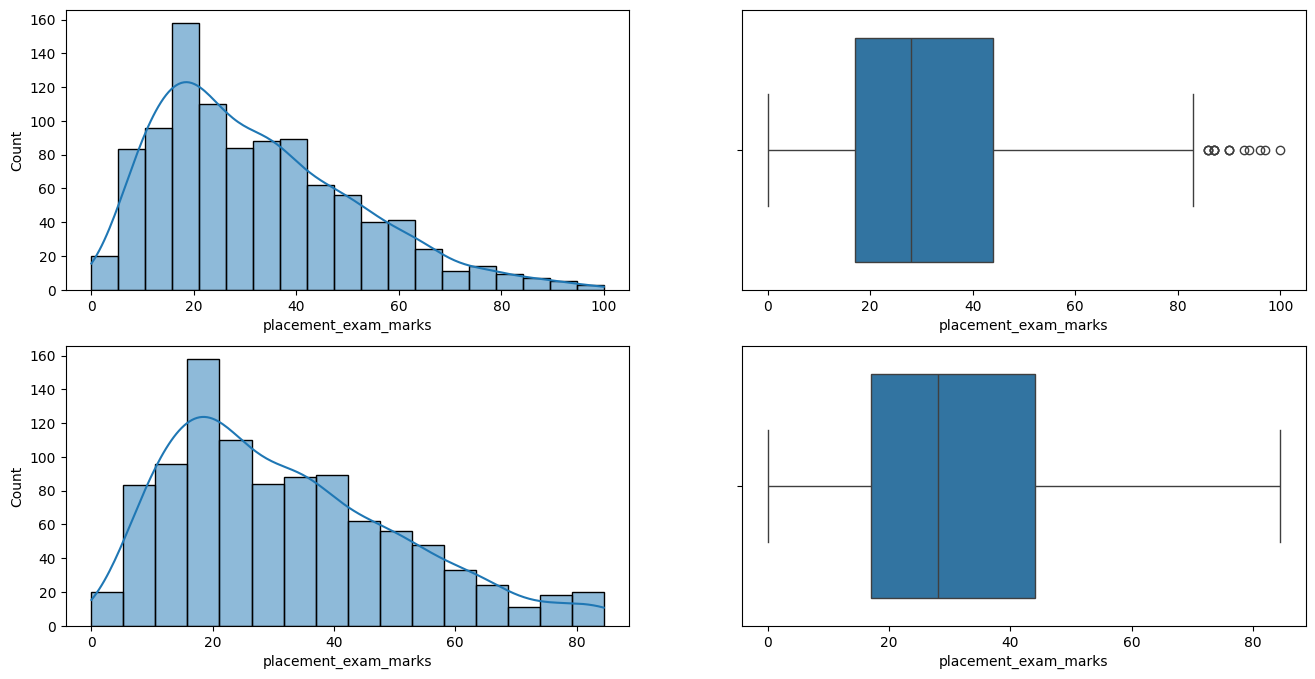

In [83]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'],orient='h')

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'],orient='h')